# VAMPS Demo — Fiji pine forest

Python port of the classic `vamps_demo` S-Lang script.  The original demo
drove gnuplot live during a run; here we use `Model.from_file()` and
`run_stepwise()` to do the same in a notebook.

What the original demo did, and the equivalent here:

| Original (S-Lang / gnuplot) | This notebook |
|-----------------------------|---------------|
| `evalfile("iplot.sl")` — plot input forcing | Section 2 |
| `allsoilplots()` — Van Genuchten retention curves | Section 3 |
| `v_run()` + `each_step()` — live volact + howsat profile | Section 4–5 |
| `evalfile("vfit.sl")` — parameter fitting | Section 6 |

**Setup** (once from the repo root):
```bash
pip install -e .
```

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

REPO     = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
DATA_DIR = os.path.join(REPO, 'examples', 'vamps_demo')
INP      = os.path.join(DATA_DIR, 'fiji.inp')
sys.path.insert(0, REPO)

from vampspy import Model
from vampspy.forcing import read_ts_timed
from vampspy._io import parse_inp

print('data dir:', DATA_DIR)
print('inp file:', INP)

data dir: /Users/jaap/Nextcloud/src/vamps/examples/vamps_demo
inp file: /Users/jaap/Nextcloud/src/vamps/examples/vamps_demo/fiji.inp


---
## 1. Load model from file

`Model.from_file()` parses `fiji.inp` and loads all forcing arrays from the
`.prn` files referenced in the `[ts]` section.  The forcing files use
absolute day numbers as the time axis; we read those separately for plotting.

In [2]:
# Load model: parses fiji.inp + reads all .prn forcing files
os.chdir(DATA_DIR)   # so relative paths in fiji.inp resolve
model = Model.from_file(INP)

# Absolute day numbers from the precipitation time axis (for plotting)
abs_t, _ = read_ts_timed(os.path.join(DATA_DIR, 'precip.prn'))
abs_t = abs_t[:model.steps]   # clip to simulation length

print(f"Steps : {model.steps}")
print(f"Days  : {abs_t[0]:.0f} … {abs_t[-1]:.0f}")
print(f"Forcing variables: {list(model.forcing.keys())}")

Steps : 61
Days  : 33056 … 33116
Forcing variables: ['pre', 'nra', 'ira', 'rlh', 'tem', 'win']


---
## 2. Input forcing  (`iplot.sl` equivalent)

The original demo plotted all input time series before the model run.

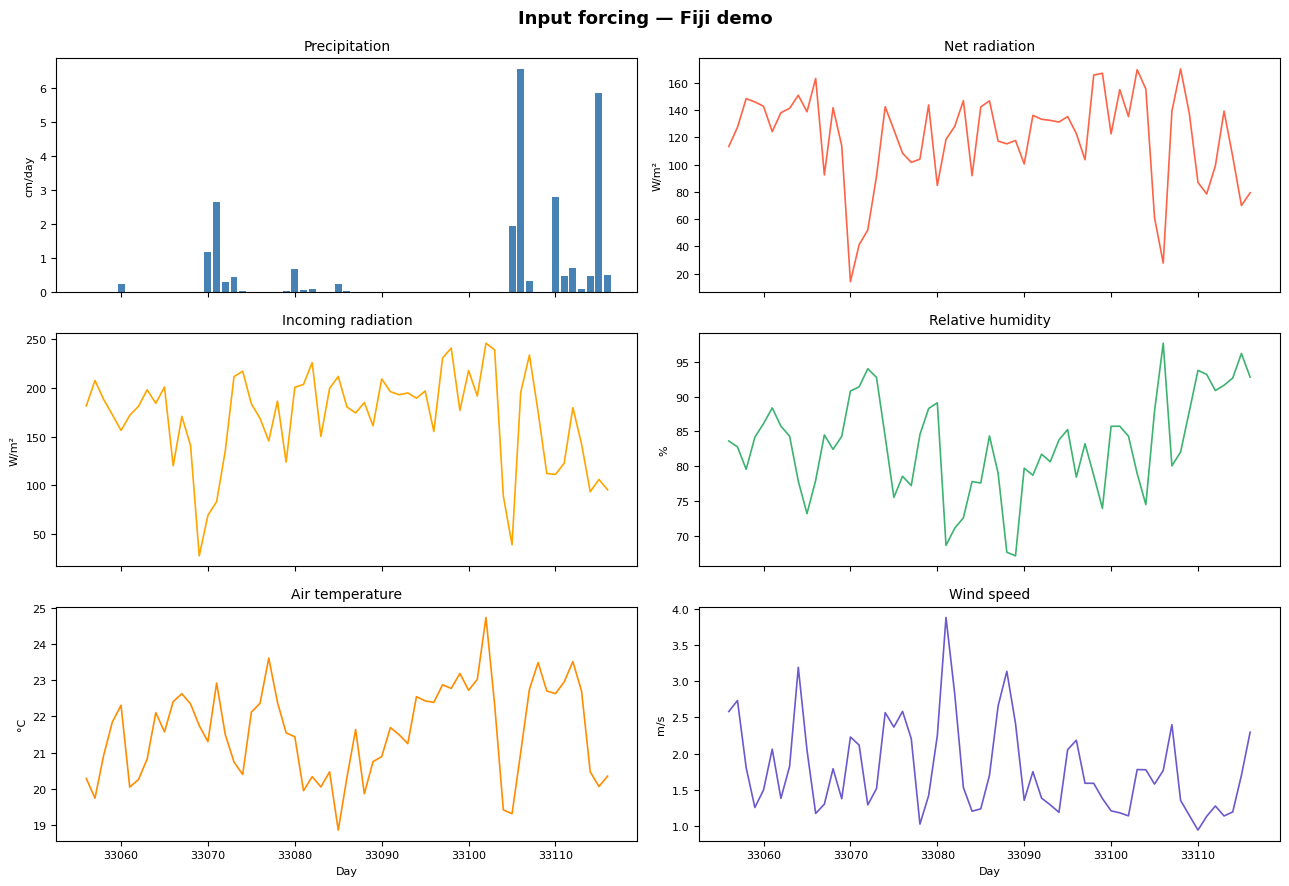

In [3]:
labels = {
    'pre': ('Precipitation',      'cm/day',  'steelblue'),
    'nra': ('Net radiation',      'W/m²',    'tomato'),
    'ira': ('Incoming radiation', 'W/m²',    'orange'),
    'rlh': ('Relative humidity',  '%',       'mediumseagreen'),
    'tem': ('Air temperature',    '°C',      'darkorange'),
    'win': ('Wind speed',         'm/s',     'slateblue'),
}

fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)
fig.suptitle('Input forcing — Fiji demo', fontsize=13, fontweight='bold')

for ax, (key, (title, unit, color)) in zip(axes.flat, labels.items()):
    arr = model.forcing[key]
    if key == 'pre':
        ax.bar(abs_t, arr, color=color, width=0.8)
    else:
        ax.plot(abs_t, arr, color=color, linewidth=1.2)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(unit, fontsize=8)
    ax.tick_params(labelsize=8)

for ax in axes[-1]:
    ax.set_xlabel('Day', fontsize=8)

plt.tight_layout()
plt.show()

---
## 3. Soil hydraulic properties  (`allsoilplots` equivalent)

The original demo called `allsoilplots()` which read the generated soil look-up
tables and plotted θ(h) and K(h) for each soil type.  Here we compute the
Van Genuchten curves analytically from the `[st_N]` parameters in the config.

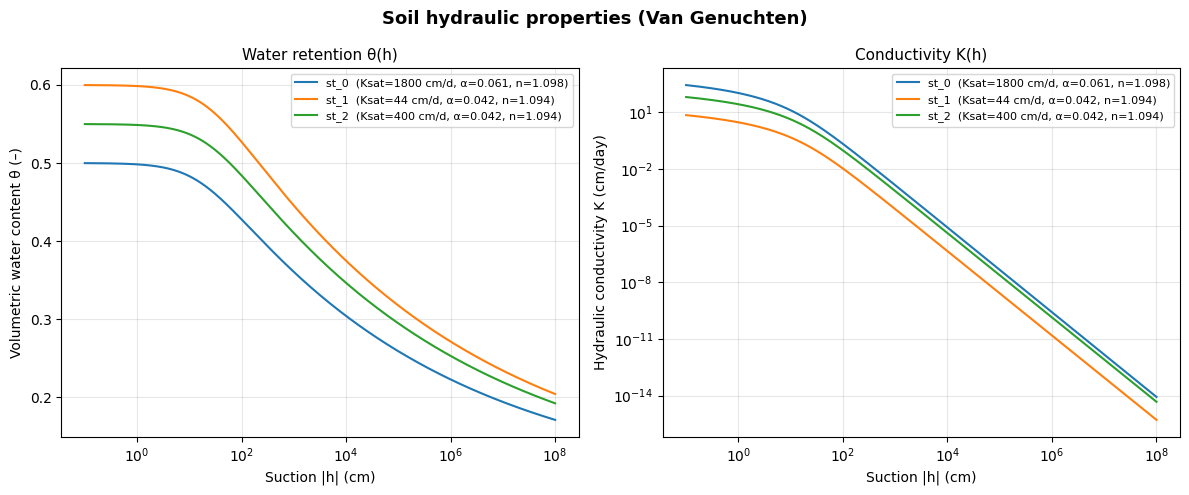

: 

In [ ]:
def vg_theta(h_cm, alpha, n, thetas, thetar):
    """Van Genuchten water retention: θ(h).  h in cm (positive = suction)."""
    m = 1 - 1/n
    Se = 1.0 / (1 + (alpha * np.abs(h_cm))**n)**m
    return thetar + (thetas - thetar) * Se

def vg_K(h_cm, alpha, n, l, ksat):
    """Van Genuchten–Mualem conductivity: K(h).  K in cm/day."""
    m = 1 - 1/n
    Se = 1.0 / (1 + (alpha * np.abs(h_cm))**n)**m
    return ksat * Se**l * (1 - (1 - Se**(1/m))**m)**2

# Read soil type parameters from the parsed config
sections = parse_inp(INP)
soil_types = {k: v for k, v in sections.items() if k.startswith('st_')}

h_range = np.logspace(-1, 8, 500)   # suction 0.1 … 10000 cm

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Soil hydraulic properties (Van Genuchten)', fontsize=13, fontweight='bold')

colors_st = ['#1f77b4', '#ff7f0e', '#2ca02c']

for (name, st), color in zip(sorted(soil_types.items()), colors_st):
    alpha  = float(st['alpha'])
    n      = float(st['n'])
    l      = float(st.get('l', 0.5))
    thetas = float(st['thetas'])
    thetar = float(st.get('theta_residual', 0.0))
    ksat   = float(st['ksat'])

    theta_h = vg_theta(h_range, alpha, n, thetas, thetar)
    K_h     = vg_K(h_range, alpha, n, l, ksat)

    label = f"{name}  (Ksat={ksat:.0f} cm/d, α={alpha}, n={n})"
    ax1.semilogx(h_range, theta_h, color=color, label=label)
    ax2.loglog(h_range, K_h,     color=color, label=label)

ax1.set_xlabel('Suction |h| (cm)', fontsize=10)
ax1.set_ylabel('Volumetric water content θ (–)', fontsize=10)
ax1.set_title('Water retention θ(h)', fontsize=11)
ax1.legend(fontsize=8)
ax1.grid(True, which='both', alpha=0.3)

ax2.set_xlabel('Suction |h| (cm)', fontsize=10)
ax2.set_ylabel('Hydraulic conductivity K (cm/day)', fontsize=10)
ax2.set_title('Conductivity K(h)', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Model run with progress  (`v_run` + `each_step` equivalent)

The original demo updated the gnuplot window every step.  Here we use
`run_stepwise()` so the Python loop is explicit; we print a compact
progress line every 5 steps.

In [ ]:
import copy, tempfile
from vampspy import _vampscore
from vampspy._io import write_inp

SCALAR_KEYS  = (
    't', 'volact', 'SMD', 'qtop', 'qbot', 'avgtheta',
    'cumprec', 'cumtra', 'cumeva', 'cumintc', 'masbal',
    'precipitation', 'interception', 'transpiration', 'soilevaporation',
)
PROFILE_KEYS = ('theta', 'k', 'h', 'q', 'inq', 'qrot', 'howsat', 'gwl')

# Build config and register forcing with the C extension
cfg = copy.deepcopy(model.config)
cfg.setdefault('time', {})['steps'] = model.steps
cfg['ts'] = {name: f'_array_{name}' for name in model.forcing}

tmpdir   = tempfile.mkdtemp(prefix='vamps_demo_')
inp_path = os.path.join(tmpdir, 'run.inp')
write_inp(cfg, inp_path, '/dev/null', {}, firststep=1)

_vampscore.soil_init(inp_path, model.forcing, 1.0)
nl = _vampscore.soil_nlayers()
print(f"Initialised: {nl} layers, {model.steps} steps\n")
print(f"{'Step':>5}  {'Day':>8}  {'volact':>8}  {'SMD':>8}  {'pre':>7}  {'tra':>7}  {'masbal':>9}")
print('-' * 62)

per_step = []
for i in range(model.steps):
    _vampscore.soil_step(i)
    state = _vampscore.soil_state(i)
    per_step.append(state)

    if i % 5 == 0 or i == model.steps - 1:
        print(f"{i+1:5d}  {abs_t[i]:8.0f}  "
              f"{state['volact']:8.3f}  {state['SMD']:8.3f}  "
              f"{state['precipitation']:7.4f}  {state['transpiration']:7.4f}  "
              f"{state['masbal']:9.5f}")

# Assemble arrays
result = {}
for key in SCALAR_KEYS:
    result[key] = np.array([s[key] for s in per_step], dtype=float)
for key in PROFILE_KEYS:
    result[key] = np.array([s[key] for s in per_step], dtype=float)
result['_steps']   = model.steps
result['_nlayers'] = nl

print(f"\nRun complete. Final mass balance error: {result['masbal'][-1]:.5f} cm")

---
## 5. Results  (volact vs measured + howsat profile)

The original demo showed two subplots every step:
- Top: simulated volact time series + field measurements as points
- Bottom: howsat depth profile for the current step

Here we show both as static figures, plus the full profile evolution as a heatmap.

In [ ]:
def read_octave_matrix(path):
    """Read an Octave-format 2-column matrix file (skips # header lines)."""
    return np.loadtxt(path, comments='#')

meas_volact = read_octave_matrix(os.path.join(DATA_DIR, 'volact.prn'))
meas_theta  = read_octave_matrix(os.path.join(DATA_DIR, 'meant.prn'))

print(f"Measured volact: {len(meas_volact)} points,  days {meas_volact[:,0].min():.0f}–{meas_volact[:,0].max():.0f}")
print(f"Measured avgθ  : {len(meas_theta)} points,  days {meas_theta[:,0].min():.0f}–{meas_theta[:,0].max():.0f}")

Measured volact: 18 points,  days 33060–33117
Measured avgθ  : 17 points,  days 33060–33112


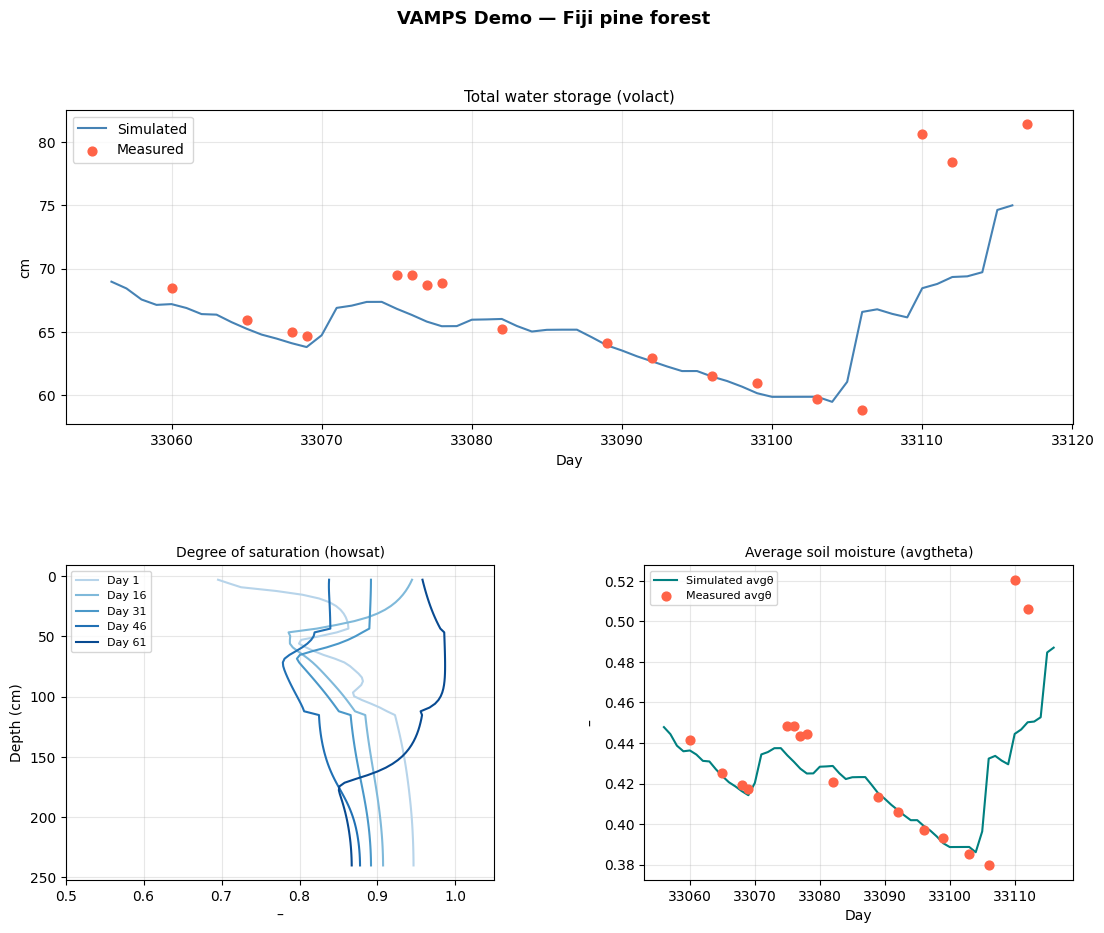

In [ ]:
layer_depth = np.arange(1, nl + 1) * (240.0 / nl)   # approx. mid-point depths [cm]

fig = plt.figure(figsize=(13, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Volact: simulated vs measured ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(abs_t, result['volact'], color='steelblue', linewidth=1.5, label='Simulated')
ax1.scatter(meas_volact[:, 0], meas_volact[:, 1],
            color='tomato', zorder=5, s=40, label='Measured')
ax1.set_title('Total water storage (volact)', fontsize=11)
ax1.set_ylabel('cm'); ax1.set_xlabel('Day')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- howsat profile at last step ---
ax2 = fig.add_subplot(gs[1, 0])
colors_hs = plt.cm.Blues(np.linspace(0.3, 0.9, 5))
for j, day_i in enumerate([0, 15, 30, 45, 60]):
    ax2.plot(result['howsat'][day_i], layer_depth,
             color=colors_hs[j], label=f'Day {day_i+1}')
ax2.invert_yaxis()
ax2.set_title('Degree of saturation (howsat)', fontsize=10)
ax2.set_xlabel('–'); ax2.set_ylabel('Depth (cm)')
ax2.set_xlim(0.5, 1.05)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# --- Average theta: simulated vs measured ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(abs_t, result['avgtheta'], color='teal', linewidth=1.5, label='Simulated avgθ')
ax3.scatter(meas_theta[:, 0], meas_theta[:, 1],
            color='tomato', zorder=5, s=40, label='Measured avgθ')
ax3.set_title('Average soil moisture (avgtheta)', fontsize=10)
ax3.set_ylabel('–'); ax3.set_xlabel('Day')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

fig.suptitle('VAMPS Demo — Fiji pine forest', fontsize=13, fontweight='bold')
plt.show()

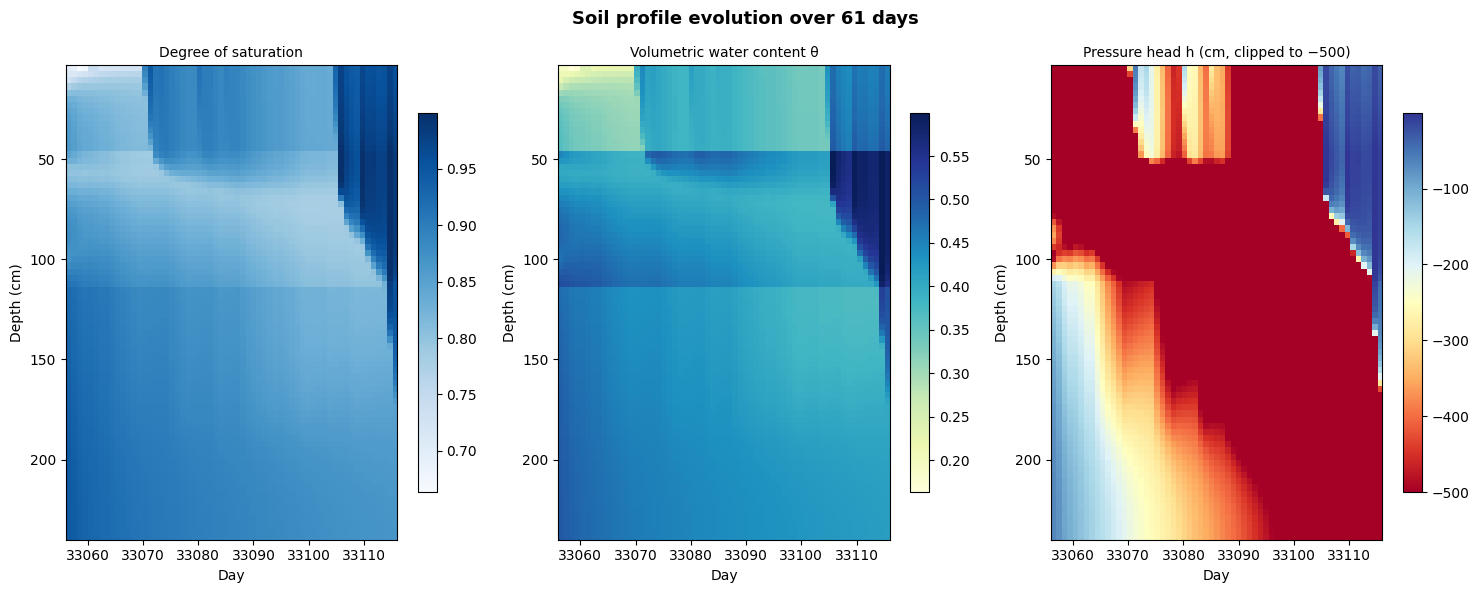

In [ ]:
# --- Profile heatmaps over time (equivalent of the per-step p_plot in the demo) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Soil profile evolution over 61 days', fontsize=13, fontweight='bold')

specs = [
    ('howsat', result['howsat'],   'Degree of saturation',        'Blues',    None),
    ('theta',  result['theta'],    'Volumetric water content θ',  'YlGnBu',   None),
    ('h',      np.clip(result['h'], -500, 0), 'Pressure head h (cm, clipped to −500)', 'RdYlBu', None),
]

for ax, (key, arr, title, cmap, _) in zip(axes, specs):
    # rows = depth (top→bottom), cols = time
    im = ax.imshow(
        arr[:, :nl].T,
        aspect='auto',
        origin='upper',
        extent=[abs_t[0], abs_t[-1], layer_depth[-1], layer_depth[0]],
        cmap=cmap,
    )
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Day')
    ax.set_ylabel('Depth (cm)')

plt.tight_layout()
plt.show()

---
## 6. Parameter fitting  (`vfit.sl` equivalent)

The original demo ran a S-Lang fitting script.  Here we use
`scipy.optimize.minimize` to calibrate two uncertain soil parameters
(`ksat` for layers st_1 and st_2) against the 18 measured `volact` values.

The objective is root-mean-square error between simulated and measured `volact`
at the observation dates.

In [ ]:
from scipy.optimize import minimize

# Observation days and values (strip points outside simulation window)
obs_mask = (meas_volact[:, 0] >= abs_t[0]) & (meas_volact[:, 0] <= abs_t[-1])
obs_t    = meas_volact[obs_mask, 0]   # absolute day numbers
obs_v    = meas_volact[obs_mask, 1]   # measured volact [cm]

# Map observation days to simulation step indices
obs_idx = np.array([np.argmin(np.abs(abs_t - d)) for d in obs_t])
print(f"Using {len(obs_t)} observations at steps: {obs_idx}")


def run_with_params(log_ksat1, log_ksat2):
    """Run the model with modified ksat values; return simulated volact array."""
    cfg2 = copy.deepcopy(model.config)
    cfg2['st_1']['ksat'] = float(10**log_ksat1)
    cfg2['st_2']['ksat'] = float(10**log_ksat2)
    cfg2.setdefault('time', {})['steps'] = model.steps
    cfg2['ts'] = {name: f'_array_{name}' for name in model.forcing}

    inp2 = os.path.join(tmpdir, 'fit.inp')
    write_inp(cfg2, inp2, '/dev/null', {}, firststep=1)
    _vampscore.soil_init(inp2, model.forcing, 1.0)
    va = np.empty(model.steps)
    for i in range(model.steps):
        _vampscore.soil_step(i)
        s = _vampscore.soil_state(i)
        va[i] = s['volact']
    return va


def objective(params):
    va = run_with_params(params[0], params[1])
    resid = va[obs_idx] - obs_v
    return np.sqrt(np.mean(resid**2))


# Initial parameter values (log10 of ksat in cm/day)
sections_orig = parse_inp(INP)
x0 = [
    np.log10(float(sections_orig['st_1']['ksat'])),
    np.log10(float(sections_orig['st_2']['ksat'])),
]
print(f"\nInitial: ksat_1={10**x0[0]:.1f}  ksat_2={10**x0[1]:.1f}  RMSE={objective(x0):.4f} cm")

result_opt = minimize(
    objective, x0,
    method='Nelder-Mead',
    options={'xatol': 0.02, 'fatol': 0.01, 'maxiter': 200, 'disp': True},
)

x_opt = result_opt.x
print(f"\nOptimised: ksat_1={10**x_opt[0]:.1f}  ksat_2={10**x_opt[1]:.1f}  RMSE={result_opt.fun:.4f} cm")

Using 17 observations at steps: [ 4  9 12 13 19 20 21 22 26 33 36 40 43 47 50 54 56]

Initial: ksat_1=44.0  ksat_2=400.0  RMSE=4.4331 cm


|        61.000000  |    0 sec.|    0  |   [ 0.518,  1,    0,0.000400,75.003] |
|        61.000000  |    0 sec.|    0  |   [ 0.518,  1,    0,0.000400,75.003] |
|        61.000000  |    0 sec.|    0  |   [ 0.543,  1,    0,0.000400,74.940] |
|        61.000000  |    1 sec.|    0  |   [ 0.885,  1,    0,0.000282,74.684] |
|        61.000000  |    0 sec.|    0  |   [ 0.357,  1,    0,0.000400,75.203] |
|        61.000000  |    0 sec.|    0  |   [ 0.190,  1,    0,0.000400,75.432] |
|        61.000000  |    0 sec.|    0  |   [ 0.167,  1,    0,0.000400,75.493] |
|        61.000000  |    0 sec.|    0  |   [-0.058,  1,    0,0.000400,75.777] |
|        61.000000  |    0 sec.|    0  |   [-0.063,  1,    0,0.000400,76.004] |
|        61.000000  |    0 sec.|    0  |   [-0.063,  1,    0,0.000400,76.298] |
|        61.000000  |    0 sec.|    0  |   [ 0.078,  1,    0,0.000400,76.323] |
|        61.000000  |    0 sec.|    0  |   [ 0.557,  1,    0,0.000400,76.136] |
|        61.000000  |    0 sec.|    0  |

Optimization terminated successfully.
         Current function value: 4.036793
         Iterations: 44
         Function evaluations: 85

Optimised: ksat_1=39.4  ksat_2=0.0  RMSE=4.0368 cm


|        61.000000  |    0 sec.|    0  |   [ 1.533,  1,    0,0.000382,75.653] |
|        61.000000  |    0 sec.|    0  |   [ 1.568,  1,    0,0.000013,75.618] |


RMSE initial  : 4.4343 cm
RMSE optimised: 4.0368 cm


|        61.000000  |    0 sec.|    0  |   [ 1.519,  1,    0,0.000062,75.667] |


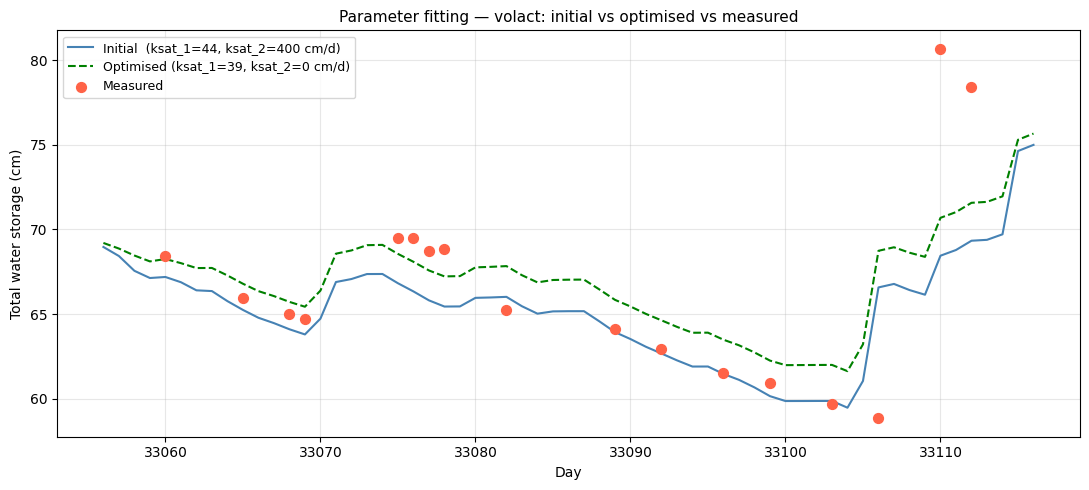

In [ ]:
va_opt = run_with_params(x_opt[0], x_opt[1])

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(abs_t, result['volact'], color='steelblue', linewidth=1.5,
        label=f'Initial  (ksat_1={10**x0[0]:.0f}, ksat_2={10**x0[1]:.0f} cm/d)')
ax.plot(abs_t, va_opt,           color='green',     linewidth=1.5, linestyle='--',
        label=f'Optimised (ksat_1={10**x_opt[0]:.0f}, ksat_2={10**x_opt[1]:.0f} cm/d)')
ax.scatter(obs_t, obs_v, color='tomato', zorder=5, s=50, label='Measured')

ax.set_title('Parameter fitting — volact: initial vs optimised vs measured', fontsize=11)
ax.set_xlabel('Day'); ax.set_ylabel('Total water storage (cm)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

rmse_init = np.sqrt(np.mean((result['volact'][obs_idx] - obs_v)**2))
rmse_opt  = np.sqrt(np.mean((va_opt[obs_idx] - obs_v)**2))
print(f"RMSE initial  : {rmse_init:.4f} cm")
print(f"RMSE optimised: {rmse_opt:.4f} cm")

plt.tight_layout()
plt.show()